# Growth within American Parliamentary Debate Association (APDA)

This section will analzye the growth of APDA from Fall 2019 to Spring 2026 using the following metrics: tournaments, rounds, and number of debaters. The goal of this section is to understand the scope of APDA and its expected impact in coming years.

## Tournaments

The first metric to understand is the number of tournaments in APDA between Fall 2019 and Spring 2026 as well as the number of tournaments per semester. In order to begin understanding this, I will import the rounds from Fall 2019 to Spring 2026, this data includes information on all the rounds conducted at tournaments with accessible tab cards between Fall 2019 and Spring 2026. This data also include information on the speakers, judges, and decisions. These are not relevant for this analysis so we will drop this extra information and begin by tallying the number of rounds per tournament to utilize in the Rounds section.

In [1]:
import pandas as pd
df_rounds = pd.read_csv("Data_Curation_Data/Rounds_After_Debater_Restoration.csv")
df_rounds = df_rounds[df_rounds["Round"] != 6]
collapsed_df = df_rounds.groupby(["Tournament", "Season", "Year"], as_index=False).count()
collapsed_df = collapsed_df[['Tournament', 'Season', 'Year', 'Round']].copy()
collapsed_df = collapsed_df.rename(columns={"Round": "Total Rounds"})
print(collapsed_df.head())

  Tournament  Season  Year  Total Rounds
0   American    Fall  2019           227
1   American    Fall  2024           129
2   American  Spring  2024            70
3   American  Spring  2025            83
4   American  Spring  2026            96


In addition to the tournaments seen in the "Rounds_Data.csv", there were also tournaments that could not be processed due to bad format, lack of permission, or because they simply had never been recorded. The code below will append these lost tournaments to our collapsed_df dataset which contains information about tournament, season, year, and number of rounds from that tournament. I will append these tournaments to our dataframe so they will be included in our analysis. Further, for some tournaments, even though the tab cards are unavaliable, the schools provided a blurb about the number of rounds or teams attending at least three rounds. I used this information to make an educated guess about the number of rounds recorded at that tournament, though these numbers may be slightly off from the true rounds.

In [2]:
grouped = df_rounds.groupby("Round")["G/O"].count()
print(grouped.head())

Round
1    3243
2    3282
3    3247
4    3183
5    3091
Name: G/O, dtype: int64


The above shows the total number of rounds that occurred in rounds one through five at tournaments from Fall 2019 to Spring 2026. Sometimes debaters are late and miss round one, while other discouraged debaters do not show up for day two (rounds four and five), this accounts for some of the discrepancies above. I will assume all debaters who will turn up for the tournament do so by round two.

In [3]:
max_rounds = grouped.loc[2]
total_rounds = grouped.loc[1] + grouped.loc[2] + grouped.loc[3] + grouped.loc[4] + grouped.loc[5]
total_normalized_rounds = total_rounds / 5
print("Percentage of Rounds Dropped: ", 1 - total_normalized_rounds/max_rounds)

Percentage of Rounds Dropped:  0.022181596587446784


Under these assumptions, the above shows us that in total only 2.22% of all rounds are dropped. Due to this, we can take the estimated values from the number of teams and use a multiplier to mimic the dropped rounds seen across other tournaments.

In [4]:
import numpy as np

data = [
    {'Tournament': 'Fordham', 'Season': 'Fall', 'Year': 2019},
    {'Tournament': 'University of Virginia', 'Season': 'Fall', 'Year': 2019, 'Total Rounds': 55}, # 22 teams, 11 rounds * 5 = 55
    {'Tournament': 'Columbia', 'Season': 'Fall', 'Year': 2019, 'Total Rounds': 245}, # 98 teams, 49 rounds * 5 = 245
    {'Tournament': 'Georgetown', 'Season': 'Spring', 'Year': 2020, 'Total Rounds': 165}, # 66 teams, 33 rounds * 5 = 165
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2020, 'Total Rounds': 55}, # 23 teams, 11 rounds * 5 = 55
    {'Tournament': 'Harvard/Pitt', 'Season': 'Fall', 'Year': 2020},
    {'Tournament': 'Swarthmore', 'Season': 'Spring', 'Year': 2021, 'Total Rounds': 105}, # 43 teams, 21 rounds * 5 = 105 
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2021, 'Total Rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'Tournament': 'William and Mary/CUNY/Stanford', 'Season': 'Spring', 'Year': 2021},
    {'Tournament': 'Georgetown/Williams', 'Season': 'Spring', 'Year': 2021, 'Total Rounds': 75}, # 31 teams, 15 rounds * 5 = 75
    {'Tournament': 'Yale', 'Season': 'Spring', 'Year': 2021, 'Total Rounds': 120}, # 49 teams, 24 rounds * 5 = 120
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2021, 'Total Rounds': 55}, # 35 teams, 11 rounds * 5 = 55
    {'Tournament': 'Brown', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 65}, # 26 teams, 13 rounds * 5 = 65
    {'Tournament': 'Princeton', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 105}, # 43 teams, 21 rounds * 5 = 105 
    {'Tournament': 'Yale', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 90}, # 36 teams, 18 rounds * 5 = 90
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 60}, # 24 teams, 12 rounds * 5 = 60
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2022, 'Total Rounds': 140},  # 56 teams, 28 rounds * 5 = 140
    {'Tournament': 'Tufts', 'Season': 'Fall', 'Year': 2022, 'Total Rounds': 115}, # 46 teams, 23 rounds * 5 = 115
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2022, 'Total Rounds': 210}, # 85 teams, 42 rounds * 5 = 210
    {'Tournament': 'Hopkins', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 30}, # 30 teams, 15 rounds * 5 = 75
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 40}, # 17 teams, 8 rounds * 5 = 40
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 170}, # 68 teams, 34 rounds * 5 = 170
    {'Tournament': 'Penn', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 80}, # 33 teams, 16 rounds * 5 = 80 
    {'Tournament': 'Williams', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 45}, # 18 teams, 9 rounds * 5 = 45 
    {'Tournament': 'University of Chicago', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 45}, # 19 teams, 9 rounds * 5 = 45 
    {'Tournament': 'Brandeis', 'Season': 'Fall', 'Year': 2023, 'Total Rounds': 45}, # 18 teams, 9 rounds * 5 = 45 
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2023, 'Total Rounds': 280}, # 112 teams, 56 rounds * 5 = 280
    {'Tournament': 'Brandeis', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 60}, # 24 teams, 12 rounds * 5 = 60 
    {'Tournament': 'Tufts', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 115}, # 46 teams, 23 rounds * 5 = 115 
    {'Tournament': 'Harvard', 'Season': 'Fall', 'Year': 2024, 'Total Rounds': 305}, # 123 teams, 61 rounds * 5 = 305
    {'Tournament': 'Tufts', 'Season': 'Fall', 'Year': 2024, 'Total Rounds': 125}, # 50 teams, 25 rounds * 5 = 125
    {'Tournament': 'Rutgers', 'Season': 'Spring', 'Year': 2025, 'Total Rounds': 110}, # 45 teams, 22 rounds * 5 = 110
    {'Tournament': 'Brandeis', 'Season': 'Fall', 'Year': 2025, 'Total Rounds': 40}, # 17 teams, 8 rounds * 5 = 40
    {'Tournament': 'Penn', 'Season': 'Spring', 'Year': 2025, 'Total Rounds': 160}, # 64 teams, 32 rounds * 5 = 160
    {'Tournament': 'Drexel', 'Season': 'Fall', 'Year': 2025, 'Total Rounds': 55}, # 22 teams, 11 rounds * 5 = 55 
    {'Tournament': 'Bates', 'Season': 'Fall', 'Year': 2025, 'Total Rounds': 60}, # 25 teams, 12 rounds * 5 = 60 
    {'Tournament': 'Binghamton', 'Season': 'Fall', 'Year': 2024, 'Total Rounds': 30}, # 13 teams, 6 rounds * 5 = 30 
    {'Tournament': 'Amherst', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 65}, # 26 teams, 13 rounds * 5 = 65 
    {'Tournament': 'Amherst', 'Season': 'Spring', 'Year': 2025, 'Total Rounds': 100}, # 40 teams, 20 rounds * 5 = 100
    {'Tournament': 'American', 'Season': 'Fall', 'Year': 2025},
    {'Tournament': 'Temple', 'Season': 'Spring', 'Year': 2026, 'Total Rounds': 130}, # 52 teams, 26 rounds * 5 = 130
    {'Tournament': 'UT Austin', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Swarthmore', 'Season': 'Fall', 'Year': 2023, 'Total Rounds': 60}, # 25 teams, 12 rounds * 5 = 60 rounds
    {'Tournament': 'University of Virginia', 'Season': 'Spring', 'Year': 2025, 'Total Rounds':90}, # 36 teams, 18 rounds * 5 = 90
    {'Tournament': 'Dartmouth', 'Season': 'Spring', 'Year': 2025},
    {'Tournament': 'Brown', 'Season': 'Fall', 'Year': 2024, 'Total Rounds': 255}, # 102 teams, 51 rounds * 5 = 255
    {'Tournament': 'University of Massachusetts', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 40}, # 17 teams, 8 rounds * 5 = 40 
    {'Tournament': 'NYU', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 75}, # 31 teams, 15 rounds * 5 = 75
    {'Tournament': 'Windsor', 'Season': 'Spring', 'Year': 2024, 'Total Rounds': 65}, # 27 teams, 13 rounds * 5 = 65
    {'Tournament': 'University of Massachusetts', 'Season': 'Spring', 'Year': 2023, 'Total Rounds': 60}, # 25 teams, 12 rounds * 5 = 60
    {'Tournament': 'Rutgers', 'Season': 'Fall', 'Year': 2022}, 
    {'Tournament': 'Dartmouth', 'Season': 'Spring', 'Year': 2022, 'Total Rounds': 60}, # 25 teams, 12 rounds * 5 = 60
    {'Tournament': 'Yale', 'Season': 'Fall', 'Year': 2022},
    {'Tournament': 'Williams', 'Season': 'Fall', 'Year': 2022}, 
]
missing_df = pd.DataFrame(data)
missing_df['Total Rounds'] = np.ceil(missing_df['Total Rounds'] * .978) # Mimic normal dropping patterns

tournament_rounds_df = pd.concat([collapsed_df, missing_df], ignore_index=True)

tournament_rounds_df["Semester"] = tournament_rounds_df["Season"] + " " + tournament_rounds_df["Year"].astype(str)

print(tournament_rounds_df.tail())
tournament_rounds_df.to_csv("APDA_Growth_Data/Tournament_Rounds.csv", index=False)

                      Tournament  Season  Year  Total Rounds     Semester
236  University of Massachusetts  Spring  2023          59.0  Spring 2023
237                      Rutgers    Fall  2022           NaN    Fall 2022
238                    Dartmouth  Spring  2022          59.0  Spring 2022
239                         Yale    Fall  2022           NaN    Fall 2022
240                     Williams    Fall  2022           NaN    Fall 2022


We can now see our tournaments with missing detailed round data have been appened onto the end of our dataframe, so we now have a record of all of our tournaments that took place.

In [5]:
print("Total Tournaments from Fall 2019 to Spring 2026: ", tournament_rounds_df["Tournament"].count())

Total Tournaments from Fall 2019 to Spring 2026:  241


There were a total of 242 tournaments between Fall 2019 and Spring 2026.

Now we can begin to analyze the number of tournaments over time in APDA. To do this, we will group out tournament_rounds_df by Semester leaving a count of the number of tournaments that occurred in each semester. I will also adjust the order of the semesters to be chronological.

In [6]:
semester_order = ['Fall 2019', 'Spring 2020', 'Spring 2021', 'Fall 2021', 'Spring 2022', 'Fall 2022', 'Spring 2023', 'Fall 2023', 'Spring 2024', 'Fall 2024', 'Spring 2025', 'Fall 2025', 'Spring 2026']
tournament_rounds_df['Semester'] = pd.Categorical(
    tournament_rounds_df['Semester'], 
    categories=semester_order, 
    ordered=True
)
tournaments_df = tournament_rounds_df.groupby(["Semester"], observed=False, as_index=False).count()

We will also create a mask to separate years during the COVID-19 in-person restrictions so that we can see our data with and without this extra burden on APDA.

In [7]:
covid_years = ["Spring 2020", "Fall 2020", "Spring 2021", "Fall 2021"]
tournaments_df_exclude_covid = tournaments_df[~tournaments_df["Semester"].isin(covid_years)].copy()
tournaments_df_exclude_covid["Semester"] = tournaments_df_exclude_covid["Semester"].cat.remove_unused_categories()

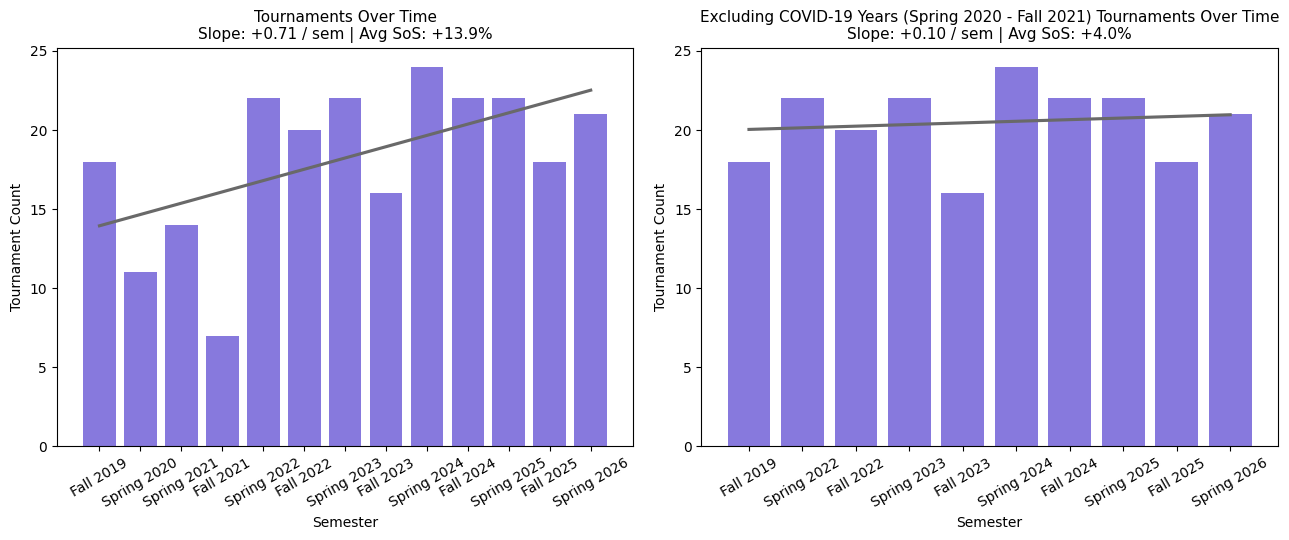

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x_positions_t = np.arange(len(tournaments_df))
slope_t, _ = np.polyfit(x_positions_t, tournaments_df["Tournament"], 1)
avg_pct_t = tournaments_df["Tournament"].pct_change().mean() * 100

x_positions_r = np.arange(len(tournaments_df_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, tournaments_df_exclude_covid["Tournament"], 1)
avg_pct_r = tournaments_df_exclude_covid["Tournament"].pct_change().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(
    tournaments_df,
    x="Semester",
    y="Tournament",
    color="mediumslateblue",
    ax=axes[0],
)
sns.regplot(
    x=x_positions_t,
    y=tournaments_df["Tournament"],
    ax=axes[0],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[0].set_title(
    f"Tournaments Over Time\nSlope: {slope_t:+.2f} / sem | Avg SoS: {avg_pct_t:+.1f}%",
    fontsize=11,
)
axes[0].set_ylabel("Tournament Count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    tournaments_df_exclude_covid,
    x="Semester",
    y="Tournament",
    color="mediumslateblue",
    ax=axes[1],
)
sns.regplot(
    x=x_positions_r,
    y=tournaments_df_exclude_covid["Tournament"],
    ax=axes[1],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[1].set_title(
    f"Excluding COVID-19 Years (Spring 2020 - Fall 2021) Tournaments Over Time\nSlope: {slope_r:+.2f} / sem | Avg SoS: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Tournament Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

From the above, we can see that the number of tournaments are increasing. In the excluding COVID-19 years graph (right), there is a slope of +0.10 a semester and has an average semester over semester increase of +4.0%. This indicates, that the number of tournaments continue to grow in ADPA. 

It also seems, from the graphics, that there might be a cyclic nature to tournaments, more in the Spring than in the Fall. I will investigate this next by performing a rudimentary analysis checking where the number of tournaments dip.

In [9]:
tournaments_df_exclude_covid['dropped'] = tournaments_df_exclude_covid['Tournament'].diff() < 0
tournaments_df_exclude_covid['cycle'] = tournaments_df_exclude_covid['dropped'].cumsum()

is_increasing = tournaments_df_exclude_covid.groupby('cycle')['Tournament'].is_monotonic_increasing
print(is_increasing)

cycle
0    True
1    True
2    True
3    True
4    True
Name: Tournament, dtype: bool


From this we can see that it is true, there are five distinct cycles of increasing before a drop appearing in our grpah. This lines up with the ten semester of data we have. So there is an increase in the Spring from the Fall and then a dip in the following Fall.

## Rounds

Now while glancing at this data I noticed something peculiar, a few tournaments, like Rutgers Spring 2024 hosted an absurdly low number of rounds - 6. So I manually inspected the tab card and found that although it existed, there was in issue in the uploading and many of the team charts, instead of listing rounds, simply said "Loading...". In order to check for other such losses lets pull up low rounds. And inspect them.

In [10]:
print(tournament_rounds_df[tournament_rounds_df["Total Rounds"] < 30])

                               Tournament  Season  Year  Total Rounds  \
8                                   Bates    Fall  2023          24.0   
9                                 Bentley    Fall  2024          23.0   
11                  Binghamton University    Fall  2021          18.0   
12                  Binghamton University    Fall  2022          25.0   
38                        Carnegie Mellon    Fall  2024          29.0   
44                               Columbia    Fall  2020          29.0   
49                  Columbia + Swarthmore  Spring  2020          20.0   
83                          Johns Hopkins  Spring  2025          29.0   
93                               Maryland  Spring  2026          28.0   
116                               Rutgers  Spring  2024           6.0   
119                                 Smith    Fall  2022          26.0   
120                                 Smith  Spring  2022          28.0   
138                                 Tufts  Spring  

In [11]:
tournament_rounds_df.loc[(tournament_rounds_df['Tournament'] == 'Rutgers') & (tournament_rounds_df['Semester'] == 'Spring 2024'), 'Total Rounds'] = 130
tournament_rounds_df.loc[(tournament_rounds_df['Tournament'] == 'Tufts') & (tournament_rounds_df['Semester'] == 'Spring 2025'), 'Total Rounds'] = 115
tournament_rounds_df.to_csv("APDA_Growth_Data/Tournaments.csv", index=False)

There only ended up being two items on the list that were problematic and both with a severe issue in the tab cards, holding 1 or 6 rounds apiece. I corrected these with the same calculation I did above and I am confident that the other tab cards do not have hidden issues like these so it is save to proceed.

In order to analyize the number of rounds in APDA, we first need to attempt to recover the data that was lost due to bad format, lack of permission, and missing tab cards. The lost number of rounds from these tournaments is data missing at random as certain schools were more likely to consistently have these issues. 

In [12]:
tournament_rounds_df[tournament_rounds_df["Total Rounds"].isna()]["Semester"].value_counts()

Semester
Fall 2022      3
Spring 2025    2
Fall 2019      1
Spring 2021    1
Fall 2025      1
Spring 2020    0
Fall 2021      0
Spring 2022    0
Spring 2023    0
Fall 2023      0
Spring 2024    0
Fall 2024      0
Spring 2026    0
Name: count, dtype: int64

From this we can see an asymetric loss centering on only a few semester with Fall 2022 and Spring 2025 being semesters with the most data lost.

In [13]:
missing_by_school = (
    tournament_rounds_df[tournament_rounds_df["Total Rounds"].isna()]["Tournament"]
    .value_counts()
)
total_by_school = tournament_rounds_df["Tournament"].value_counts()

missing_rate_by_school = (missing_by_school / total_by_school * 100).dropna().sort_values(ascending=False)
print(missing_rate_by_school.head(15))

Tournament
Harvard/Pitt                      100.000000
UT Austin                         100.000000
William and Mary/CUNY/Stanford    100.000000
Dartmouth                          33.333333
Fordham                            20.000000
American                           16.666667
Rutgers                            14.285714
Williams                           14.285714
Yale                               12.500000
Name: count, dtype: float64


Now we can see that certain schools have had all their data lost. Like before Harvard/Pitt and William and Mary/CUNY/Stanford were one off, online COVID-19 era tournaments, but we have also lost the data from UT Austin who have only hosted one tournament. We will need to simply drop these rows as we cannot feasibly reconstruct this data, luckily they are all from different years. The rest of the lost data we can recover using imputation as we have comparable tournaments from other semesters that we can use as well. We can check that we do have comparable semesters with the following:

In [14]:
for school in ["Dartmouth", "Fordham", "American", "Rutgers", "Williams", "Yale"]:
    n_available = tournament_rounds_df[tournament_rounds_df["Tournament"] == school]["Total Rounds"].notna().sum()
    print(school, n_available, "rows with rounds data available")

Dartmouth 2 rows with rounds data available
Fordham 4 rows with rounds data available
American 5 rows with rounds data available
Rutgers 6 rows with rounds data available
Williams 6 rows with rounds data available
Yale 7 rows with rounds data available


Since there are two or more tournaments per missing data, we can safely impute the missing number of rounds.

In [16]:
schools_to_impute = ["Fordham", "American", "Dartmouth", "Rutgers", "Yale", "Williams"]

mask = tournament_rounds_df["Tournament"].isin(schools_to_impute)
tournament_rounds_df.loc[mask, "Total Rounds"] = (
    tournament_rounds_df.loc[mask]
    .groupby("Tournament")["Total Rounds"]
    .transform(lambda x: x.fillna(x.median()))
    .round()
)

tournament_rounds_clean = tournament_rounds_df.dropna(subset=["Total Rounds"]).copy()
print(f"{tournament_rounds_df['Total Rounds'].isna().sum()} still missing")
tournament_rounds_clean.to_csv("APDA_Growth_Data/Tournament_Rounds.csv", index=False)

3 still missing


This cleanly imputes the 7 missing rows and drops the three unsavable rows. Now we can visualize the rounds over time for APDA. We will begin with sorting and the COVID mask.

In [17]:
semester_order = ['Fall 2019', 'Spring 2020', 'Spring 2021', 'Fall 2021', 'Spring 2022', 'Fall 2022', 'Spring 2023', 'Fall 2023', 'Spring 2024', 'Fall 2024', 'Spring 2025', 'Fall 2025', 'Spring 2026']
tournament_rounds_clean['Semester'] = pd.Categorical(
    tournament_rounds_clean['Semester'], 
    categories=semester_order, 
    ordered=True
)
total_rounds_df = tournament_rounds_clean.groupby(["Semester"], observed=False, as_index=False).count()

covid_years = ["Spring 2020", "Fall 2020", "Spring 2021", "Fall 2021"]
total_rounds_exclude_covid = total_rounds_df[~total_rounds_df["Semester"].isin(covid_years)].copy()
total_rounds_exclude_covid["Semester"] = total_rounds_exclude_covid["Semester"].cat.remove_unused_categories()

In [18]:
print("Total Number of Rounds from Fall 2019 to Spring 2026: ", tournament_rounds_clean["Total Rounds"].sum())

Total Number of Rounds from Fall 2019 to Spring 2026:  21422.0


Now we can see that there are 21,422 rounds of APDA debate between Fall 2019 and Spring 2026.

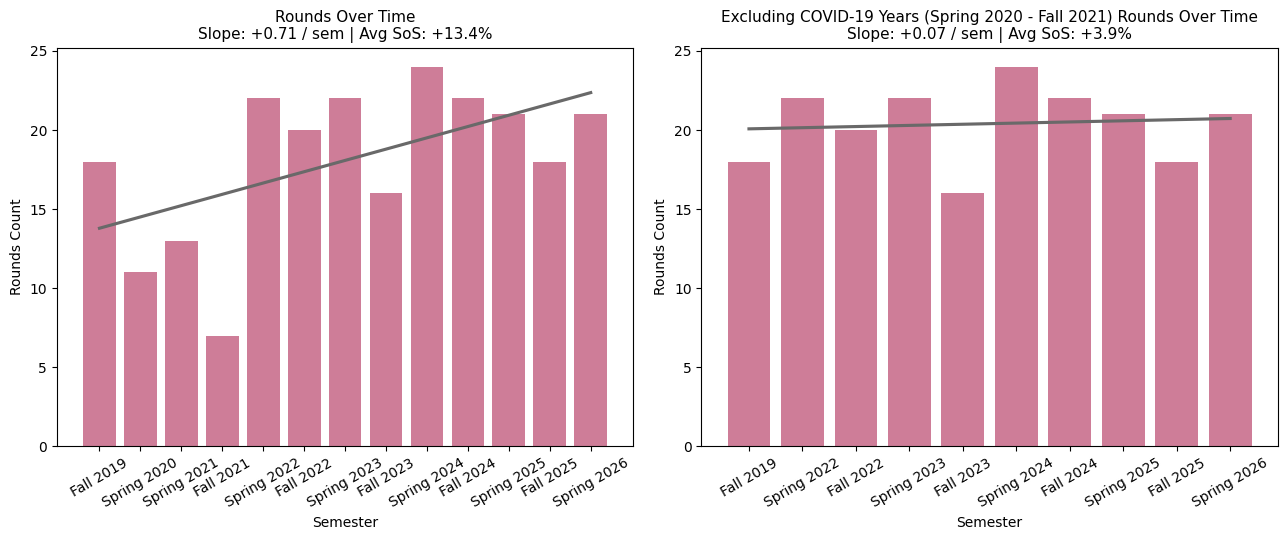

In [19]:
x_positions_t = np.arange(len(total_rounds_df))
slope_t, _ = np.polyfit(x_positions_t, total_rounds_df["Total Rounds"], 1)
avg_pct_t = total_rounds_df["Total Rounds"].pct_change().mean() * 100

x_positions_r = np.arange(len(total_rounds_exclude_covid))
slope_r, _ = np.polyfit(x_positions_r, total_rounds_exclude_covid["Tournament"], 1)
avg_pct_r = total_rounds_exclude_covid["Tournament"].pct_change().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(
    total_rounds_df,
    x="Semester",
    y="Total Rounds",
    color="palevioletred",
    ax=axes[0],
)
sns.regplot(
    x=x_positions_t,
    y=total_rounds_df["Total Rounds"],
    ax=axes[0],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[0].set_title(
    f"Rounds Over Time\nSlope: {slope_t:+.2f} / sem | Avg SoS: {avg_pct_t:+.1f}%",
    fontsize=11,
)
axes[0].set_ylabel("Rounds Count")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    total_rounds_exclude_covid,
    x="Semester",
    y="Total Rounds",
    color="palevioletred",
    ax=axes[1],
)
sns.regplot(
    x=x_positions_r,
    y=total_rounds_exclude_covid["Total Rounds"],
    ax=axes[1],
    scatter=False,
    color="dimgray",
    label="Trend",
    ci=None,
)

axes[1].set_title(
    f"Excluding COVID-19 Years (Spring 2020 - Fall 2021) Rounds Over Time\nSlope: {slope_r:+.2f} / sem | Avg SoS: {avg_pct_r:+.1f}%",
    fontsize=11,
)
axes[1].set_ylabel("Rounds Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

From this, we can see that the slope of rounds is +0.07 in the graph excluding COVID-19 (right), and that there is an average semester-over-semester increase of +3.9%. This indicates that there is growth within the number of APDA rounds as well as in the number of tournaments. Additionally, similar to the tournaments, there seems to be a cyclic effect on the number of rounds, with Fall semesters tending to be lower than the following Spring. This is with the notable exception of Fall 2024 which does have more rounds that Spring 2025.

## Deabters

The next metric which we can use to see APDA's growth is the number of active debaters.

## Insights and Conclusions

Tournament -- 241, inc, and cyclic (further, what regions? public expansion? tournaments that die out?)

Rounds -- 21,422 rounds, inc, cyclic (execption) (further, what regions? public expansion?)